| Company        | Ticker |
| -------------- | ------ |
| Microsoft      | MSFT   |
| Apple          | AAPL   |
| Amazon         | AMZN   |
| Tesla, Inc.    | TSLA   |
| NVIDIA         | NVDA   |

### India Stocks
| Company                   | Ticker      |
| ------------------------- | ----------- |
| Reliance Industries       | RELIANCE.NS |
| Tata Consultancy Services | TCS.NS      |
| Infosys                   | INFY.NS     |
| HDFC Bank                 | HDFCBANK.NS |
    
### Indices
| Index                        | Ticker |
| ---------------------------- | ------ |
| S&P 500                      | ^GSPC  |
| NIFTY 50                     | ^NSEI  |


In [59]:
import yfinance as yf

data = yf.download("MSFT", start="2020-01-01")

# print(data)

data.to_csv("msft.csv")

[*********************100%***********************]  1 of 1 completed


In [1]:
import pandas as pd

df = pd.read_csv('msft.csv')

df.head()
df.tail()

,Price,Close,High,Low,Open,Volume
1573,2026-04-06,372.8800048828125,373.7300109863281,369.5,373.489990234375,16146600
1574,2026-04-07,372.2900085449219,372.45001220703125,366.55999755859375,370.3399963378906,21443300
1575,2026-04-08,374.3299865722656,385.0,371.4100036621094,384.9800109863281,33064800
1576,2026-04-09,373.07000732421875,373.5,367.04998779296875,372.5,30435300
1577,2026-04-10,370.8699951171875,375.6400146484375,370.0299987792969,372.9800109863281,28038000


In [2]:
df = df.dropna()
df = df.drop_duplicates()

In [3]:
# reset index so Date becomes a column
df = df.drop(0)   # removes row with index 0,1
df = df.reset_index(drop=True)
df = df.rename(columns={"Price": "Date",})
# rename columns
df.head()

,Date,Close,High,Low,Open,Volume
0,2020-01-02,152.15843200683594,152.26263771533866,149.9890770179385,150.41536784183276,22622100
1,2020-01-03,150.2637176513672,151.52365350919996,149.7332213859511,149.9795335484222,21116200
2,2020-01-06,150.65213012695312,150.7184493912366,148.26488234672686,148.8048610818125,20813700
3,2020-01-07,149.27853393554688,151.2584272318134,149.03223619242732,150.92687424549183,21634100
4,2020-01-08,151.6563262939453,152.32892928184137,149.6290637970409,150.55743255975017,27746500


In [4]:
df = df[['Date','Close']]

In [5]:
df.dtypes

Date     str
Close    str
dtype: object

In [6]:
cols = df.columns.drop(["Date"])
df[cols] = df[cols].astype(float)

In [7]:
df.dtypes

Date         str
Close    float64
dtype: object

In [8]:
import datetime

def str_to_datetime(s):
  split = s.split('-')
  year, month, day = int(split[0]), int(split[1]), int(split[2])
  return datetime.datetime(year=year, month=month, day=day)

datetime_object = str_to_datetime('1986-03-19')
datetime_object

datetime.datetime(1986, 3, 19, 0, 0)

In [9]:
df['Date'] = df['Date'].apply(str_to_datetime)
df['Date']

0      2020-01-02
1      2020-01-03
2      2020-01-06
3      2020-01-07
4      2020-01-08
          ...    
1571   2026-04-06
1572   2026-04-07
1573   2026-04-08
1574   2026-04-09
1575   2026-04-10
Name: Date, Length: 1576, dtype: datetime64[us]

In [10]:
df.index = df.pop('Date')
df

,Close
Date,
2020-01-02,152.158432
2020-01-03,150.263718
2020-01-06,150.652130
2020-01-07,149.278534
2020-01-08,151.656326
...,...
2026-04-06,372.880005
2026-04-07,372.290009
2026-04-08,374.329987


In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[cols]= scaler.fit_transform(df[cols])

In [12]:
import joblib

joblib.dump(scaler, "stock_scaler.pkl")

['stock_scaler.pkl']

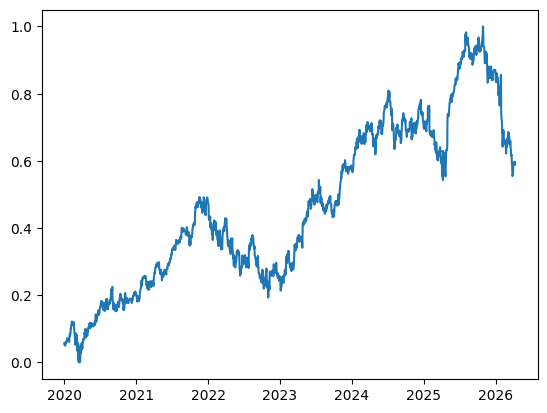

In [13]:
import matplotlib.pyplot as plt

plt.plot(df.index, df['Close'])

##  Visual Example

### Dataset
```
Mar 22
Mar 23
Mar 24
Mar 25
Mar 26
Mar 29 ← next trading day
```

### For `n = 3`

Input: `[Mar22, Mar23, Mar24]`  
Target: `Mar25`

### Next iteration : find the next days in 7 days range in Mar 25 -> 25,26,29,.....

Input: `[Mar23, Mar24, Mar25]`  
Target: `Mar26`

### Next iteration : find the next days in 7 days range in Mar 26 -> 26,29,.....

Input: `[Mar24, Mar25, Mar26]`  
Target: `Mar29`


In [14]:
import numpy as np

def df_to_windowed_df(dataframe, first_date_str, last_date_str, n=3):
  first_date = str_to_datetime(first_date_str)
  last_date  = str_to_datetime(last_date_str)

  target_date = first_date

  dates = []
  X, Y = [], []

  last_time = False
  while True:
    df_subset = dataframe.loc[:target_date].tail(n+1)

    if len(df_subset) != n+1:
      print(f'Error: Window of size {n} is too large for date {target_date}')
      return

    values = df_subset['Close'].to_numpy()
    x, y = values[:-1], values[-1]

    dates.append(target_date)
    X.append(x)
    Y.append(y)

    # stock markets are closed on sat,sun adn holidays so no data available for those days
    # so we seach for the days which  falls in the next 7 days of the target date to choose the next trading date
    next_week = dataframe.loc[target_date:target_date+datetime.timedelta(days=7)] 
    # chooses the next trading day top one is the previous trading day ,next one is the next trading day
    next_datetime_str = str(next_week.head(2).tail(1).index.values[0]) 
    next_date_str = next_datetime_str.split('T')[0]
    next_date = str_to_datetime(next_date_str)

    if last_time:
      break

    target_date = next_date

    if target_date == last_date:
      last_time = True

  ret_df = pd.DataFrame({})
  ret_df['Target Date'] = dates

  X = np.array(X)
  for i in range(0, n):
    X[:, i]
    ret_df[f'Target-{n-i}'] = X[:, i]

  ret_df['Target'] = Y

  return ret_df

# Start day second time around: '2021-03-25'
windowed_df = df_to_windowed_df(df,
                                '2020-02-01',
                                '2026-04-10',
                                n=16)
windowed_df

,Target Date,Target-16,Target-15,Target-14,Target-13,Target-12,Target-11,Target-10,Target-9,Target-8,Target-7,Target-6,Target-5,Target-4,Target-3,Target-2,Target-1,Target
0,2020-02-01,0.055984,0.060592,0.058864,0.063333,0.060684,0.063103,0.069991,0.072134,0.070752,0.068909,0.071258,0.067388,0.061029,0.068356,0.074300,0.085220,0.079345
1,2020-02-04,0.058864,0.063333,0.060684,0.063103,0.069991,0.072134,0.070752,0.068909,0.071258,0.067388,0.061029,0.068356,0.074300,0.085220,0.079345,0.088906,0.102130
2,2020-02-05,0.063333,0.060684,0.063103,0.069991,0.072134,0.070752,0.068909,0.071258,0.067388,0.061029,0.068356,0.074300,0.085220,0.079345,0.088906,0.102130,0.101623
3,2020-02-06,0.060684,0.063103,0.069991,0.072134,0.070752,0.068909,0.071258,0.067388,0.061029,0.068356,0.074300,0.085220,0.079345,0.088906,0.102130,0.101623,0.110217
4,2020-02-07,0.063103,0.069991,0.072134,0.070752,0.068909,0.071258,0.067388,0.061029,0.068356,0.074300,0.085220,0.079345,0.088906,0.102130,0.101623,0.110217,0.110816
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1550,2026-04-06,0.664472,0.649127,0.659827,0.658514,0.639982,0.633246,0.615857,0.618605,0.593653,0.589519,0.577189,0.554815,0.560141,0.587403,0.585458,0.595404,0.593994
1551,2026-04-07,0.649127,0.659827,0.658514,0.639982,0.633246,0.615857,0.618605,0.593653,0.589519,0.577189,0.554815,0.560141,0.587403,0.585458,0.595404,0.593994,0.592559
1552,2026-04-08,0.659827,0.658514,0.639982,0.633246,0.615857,0.618605,0.593653,0.589519,0.577189,0.554815,0.560141,0.587403,0.585458,0.595404,0.593994,0.592559,0.597520
1553,2026-04-09,0.658514,0.639982,0.633246,0.615857,0.618605,0.593653,0.589519,0.577189,0.554815,0.560141,0.587403,0.585458,0.595404,0.593994,0.592559,0.597520,0.594456


In [15]:
def windowed_df_to_date_X_y(windowed_dataframe):
  df_as_np = windowed_dataframe.to_numpy()

  dates = df_as_np[:, 0]

  middle_matrix = df_as_np[:, 1:-1]
  X = middle_matrix.reshape((len(dates), middle_matrix.shape[1], 1))

  Y = df_as_np[:, -1]

  return dates, X.astype(np.float32), Y.astype(np.float32)

dates, X, y = windowed_df_to_date_X_y(windowed_df)

dates.shape, X.shape, y.shape

((1555,), (1555, 16, 1), (1555,))

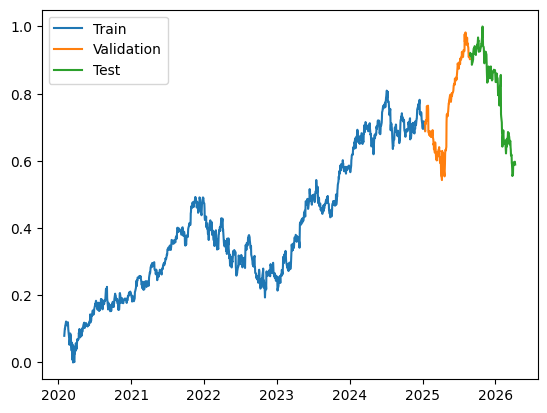

In [16]:
q_80 = int(len(dates) * .8)
q_90 = int(len(dates) * .9)
# 80% → Training
# 10% → Validation
# 10% → Testing

dates_train, X_train, y_train = dates[:q_80], X[:q_80], y[:q_80]

dates_val, X_val, y_val = dates[q_80:q_90], X[q_80:q_90], y[q_80:q_90]
dates_test, X_test, y_test = dates[q_90:], X[q_90:], y[q_90:]

plt.plot(dates_train, y_train)
plt.plot(dates_val, y_val)
plt.plot(dates_test, y_test)

plt.legend(['Train', 'Validation', 'Test'])

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers

model = Sequential([layers.Input((40, 1)),
                    layers.LSTM(64),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(32, activation='relu'),
                    layers.Dense(1)])

model.compile(loss='mse',
              optimizer=Adam(learning_rate=0.001),
              metrics=['mean_absolute_error'])

model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=200)

Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0921 - mean_absolute_error: 0.2376 - val_loss: 0.0419 - val_mean_absolute_error: 0.1929
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0051 - mean_absolute_error: 0.0541 - val_loss: 0.0016 - val_mean_absolute_error: 0.0315
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 6.6456e-04 - mean_absolute_error: 0.0207 - val_loss: 0.0013 - val_mean_absolute_error: 0.0287
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 5.5178e-04 - mean_absolute_error: 0.0186 - val_loss: 0.0014 - val_mean_absolute_error: 0.0305
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.9295e-04 - mean_absolute_error: 0.0177 - val_loss: 0.0014 - val_mean_absolute_error: 0.0305
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 5.1509e-04 - mean_absolute_error: 0.0180 - val_loss: 0.0012 - val_mean_absolute_error: 0.0285
Epoch 7/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 4.7291e-04 - mean_absolu

39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


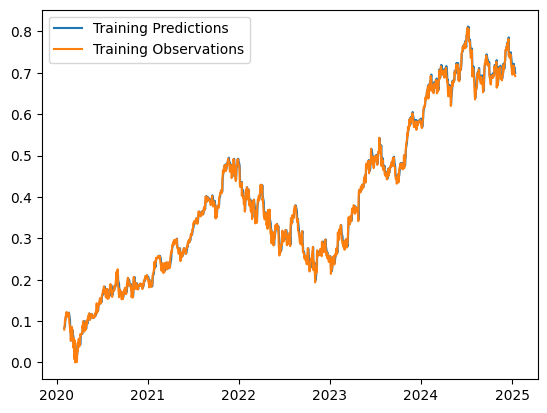

In [18]:
train_predictions = model.predict(X_train).flatten()

plt.plot(dates_train, train_predictions)
plt.plot(dates_train, y_train)
plt.legend(['Training Predictions', 'Training Observations'])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


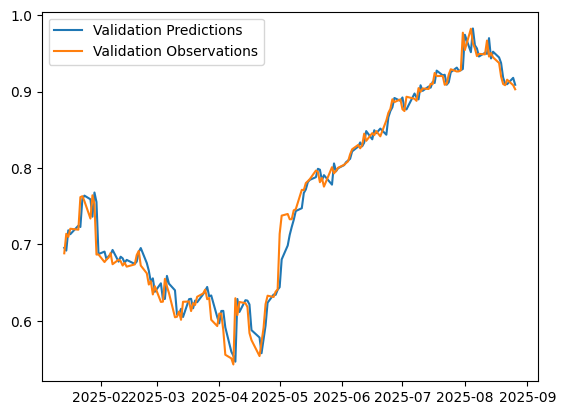

In [19]:
val_predictions = model.predict(X_val).flatten()

plt.plot(dates_val, val_predictions)
plt.plot(dates_val, y_val)
plt.legend(['Validation Predictions', 'Validation Observations'])

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


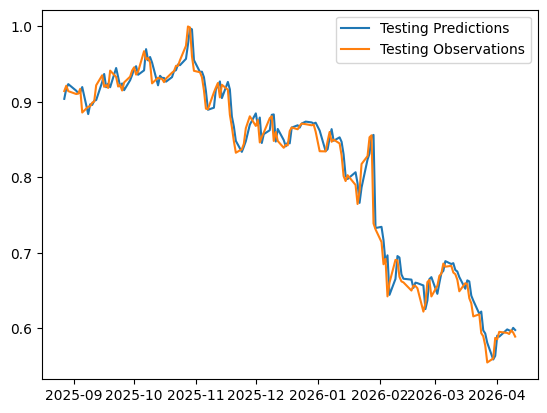

In [20]:
test_predictions = model.predict(X_test).flatten()

plt.plot(dates_test, test_predictions)
plt.plot(dates_test, y_test)
plt.legend(['Testing Predictions', 'Testing Observations'])

In [21]:
model.save("microsoft_lstm_stock_model.keras")

In [23]:
import yfinance as yf
import numpy as np
import joblib
from tensorflow import keras

# load model
# model = keras.models.load_model("E:/3rd_sem_project/stock_price_predictor_models/models/msft/microsoft_stock_model.keras")

# load scaler
scaler = joblib.load("E:/3rd_sem_project/stock_price_predictor_models/v1/stock_scaler.pkl")

# choose ticker
ticker = "MSFT"

# download last 40 days (to ensure 20 trading days)
data = yf.download(ticker, period="80d")

print(data)

# take last 20 closing prices
prices = data["Close"].tail(40).values

# scale prices
scaled = scaler.transform(prices.reshape(-1,1))

# reshape for model (1 sample, 20 timesteps, 1 feature)
X_input = scaled.reshape(1,40,1)

# predict
pred_scaled = model.predict(X_input)

# convert back to real price
pred_price = scaler.inverse_transform(pred_scaled)

print("Predicted next price:", pred_price[0][0])

[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker            MSFT        MSFT        MSFT        MSFT      MSFT
Date                                                                
2025-12-15  473.738708  479.625266  471.443928  479.006683  23727700
2025-12-16  475.305145  476.801729  469.807683  470.835336  20705600
2025-12-17  475.035736  478.906905  473.918292  475.823946  24527200
2025-12-18  482.877869  488.485066  476.801741  477.101045  28573500
2025-12-19  484.813446  486.739044  481.391234  486.250139  70836100
...                ...         ...         ...         ...       ...
2026-04-06  372.880005  373.730011  369.500000  373.489990  16146600
2026-04-07  372.290009  372.450012  366.559998  370.339996  21443300
2026-04-08  374.329987  385.000000  371.410004  384.980011  33064800
2026-04-09  373.070007  373.500000  367.049988  372.500000  30435300
2026-04-10  370.869995  375.640015  370.029999  372.980011  28038000

[80 rows x 5 columns]
1/1 ━━━━━━━


E:\3rd_sem_project\stock_price_predictor_models\v1\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
